In [1]:
import tensorflow.keras as tf
import matplotlib.pyplot as plt
import numpy as np

In [2]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [3]:
datagen = ImageDataGenerator(rescale = 1./255)

In [4]:
train_generator = datagen.flow_from_directory("Datasets/dataset/training_set", target_size=(64,64), class_mode='binary')

Found 7115 images belonging to 2 classes.


In [5]:
test_generator = datagen.flow_from_directory("Datasets/dataset/test_set", target_size=(64,64), class_mode='binary')

Found 496 images belonging to 2 classes.


In [6]:
train_generator

In [7]:
data, label = next(train_generator)
data.shape

(32, 64, 64, 3)

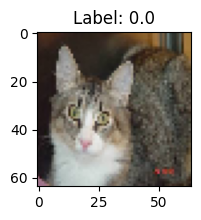

In [8]:
plt.figure(figsize=(2,2))
plt.imshow(data[12])
plt.title(f'Label: {label[12]}')
plt.show()

In [9]:
cnn = tf.models.Sequential()
cnn.add(tf.layers.Conv2D(filters = 32, kernel_size = 3, activation = 'relu', input_shape=[64, 64, 3]))
cnn.add(tf.layers.MaxPool2D(pool_size = 2, strides = 2))
cnn.add(tf.layers.Conv2D(filters = 32, kernel_size = 3, activation = 'relu'))
cnn.add(tf.layers.MaxPool2D(pool_size = 2, strides = 2))
cnn.add(tf.layers.Flatten())
cnn.add(tf.layers.Dense(units = 128, activation = 'relu'))
cnn.add(tf.layers.Dense(units = 1, activation = 'sigmoid'))

C:\Users\User\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [10]:
cnn.compile(optimizer = 'adam', loss='binary_crossentropy', metrics=['accuracy'])

In [11]:
cnn.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 62, 62, 32)          │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 31, 31, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 29, 29, 32)          │           9,248 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 14, 14, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 6272)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │         802,944 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │             129 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 813,217 (3.10 MB)

 Trainable params: 813,217 (3.10 MB)

 Non-trainable params: 0 (0.00 B)

In [12]:
result = cnn.fit(x = train_generator, epochs = 1)

223/223 ━━━━━━━━━━━━━━━━━━━━ 184s 803ms/step - accuracy: 0.6323 - loss: 0.6397


In [13]:
cnn.evaluate(test_generator)

16/16 ━━━━━━━━━━━━━━━━━━━━ 11s 639ms/step - accuracy: 0.7843 - loss: 0.5072


[0.5071607828140259, 0.7842742204666138]

In [14]:
from keras.preprocessing import image

In [15]:
from keras.utils import load_img
from keras.utils import img_to_array

In [16]:
new_image = load_img("Datasets/dataset/single_prediction/cat_or_dog_1.jpg", target_size = (64,64))

In [17]:
new_image = img_to_array(new_image)

In [18]:
new_image = np.expand_dims(new_image, axis = 0)

In [19]:
result = cnn.predict(new_image)
print(result)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 264ms/step
[[1.]]


In [20]:
if result[0][0] >=0.5:
    prediction = 'dog'
else:
    prediction = 'cat'

prediction

'dog'